=== STARTING THE BULLETPROOF 5-MODEL ABLATION PIPELINE ===

Fitting Baseline Models with Safe NaN Imputation...

Extracting CLOUD (MCMC) Parameters (-Lambda * Phi mapped)...

Aggregating Results...
Generating Final Publication Visuals in PNG, SVG, and PDF formats...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. Naive LMM  2. Ordinal / IRT  3. Discrete AR(1)  5. LPMM Approximation  4. CLOUD (IRT+OU)
Target                                                                                                  
Total Score        {:.3f}            {:.3f}             {:.3f}                 {:.3f}             {:.3f}
Bulbar             {:.3f}            {:.3f}             {:.3f}                 {:.3f}             {:.3f}
Fine_Motor         {:.3f}            {:.3f}             {:.3f}                 {:.3f}             {:.3f}
Gross_Motor        {:.3f}            {:.3f}             {:.3f}                 {:.3f}             {:.3f}
Respiratory        {:.3f}           

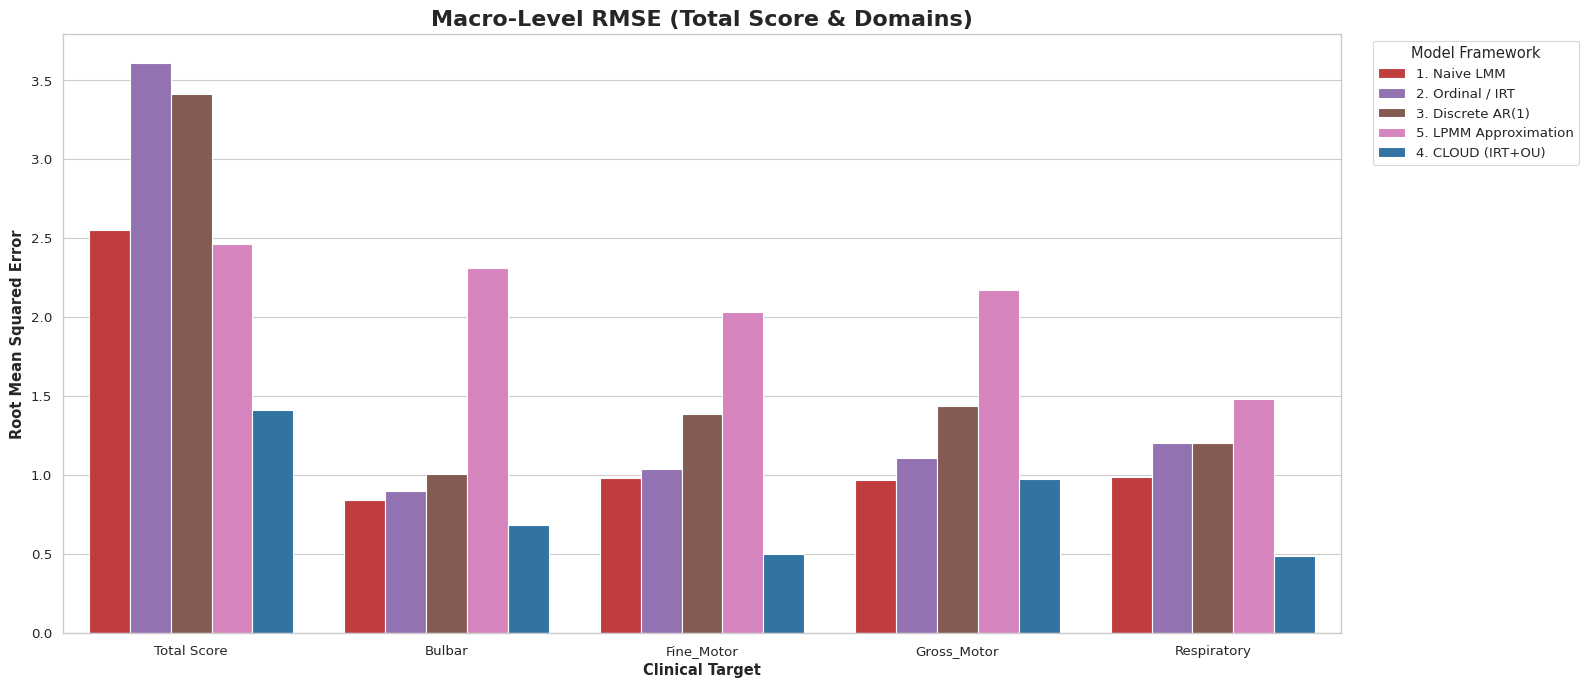

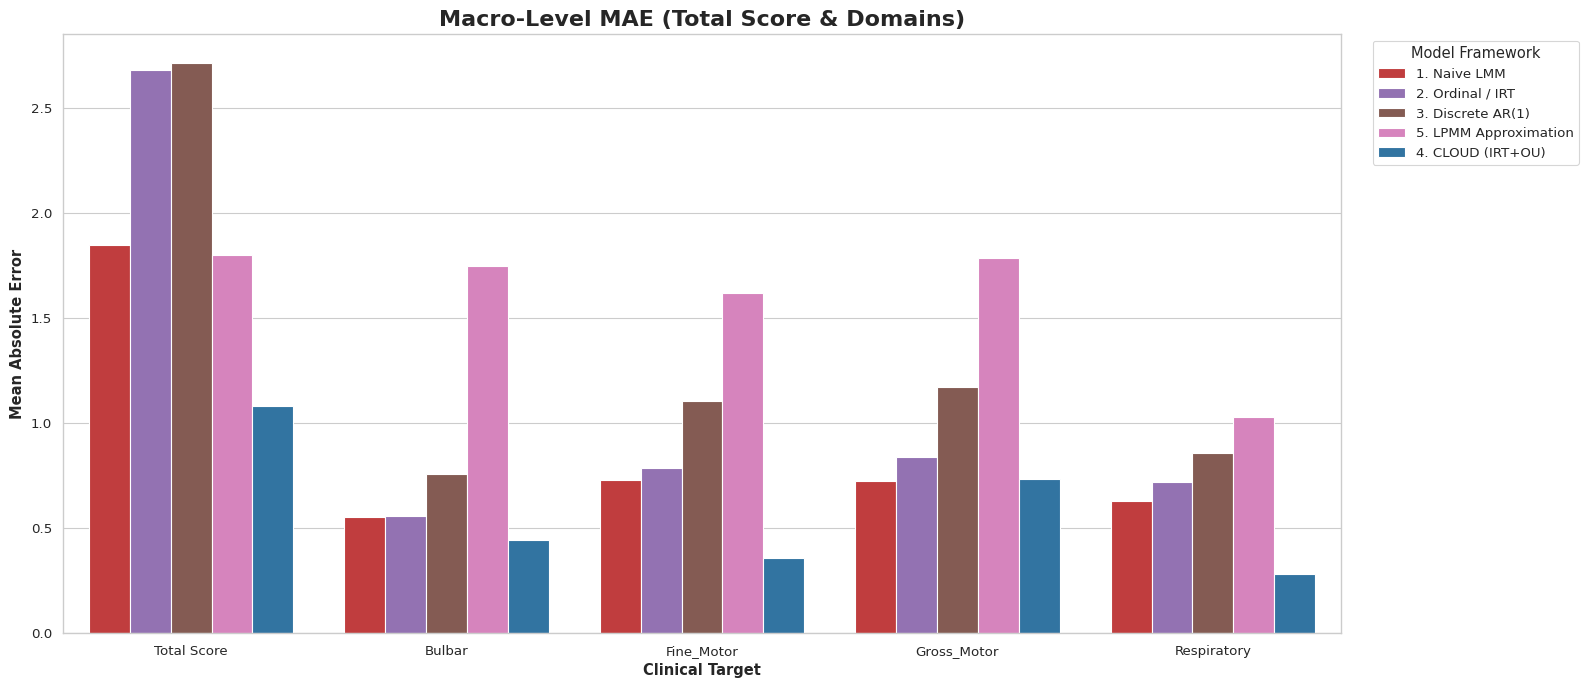

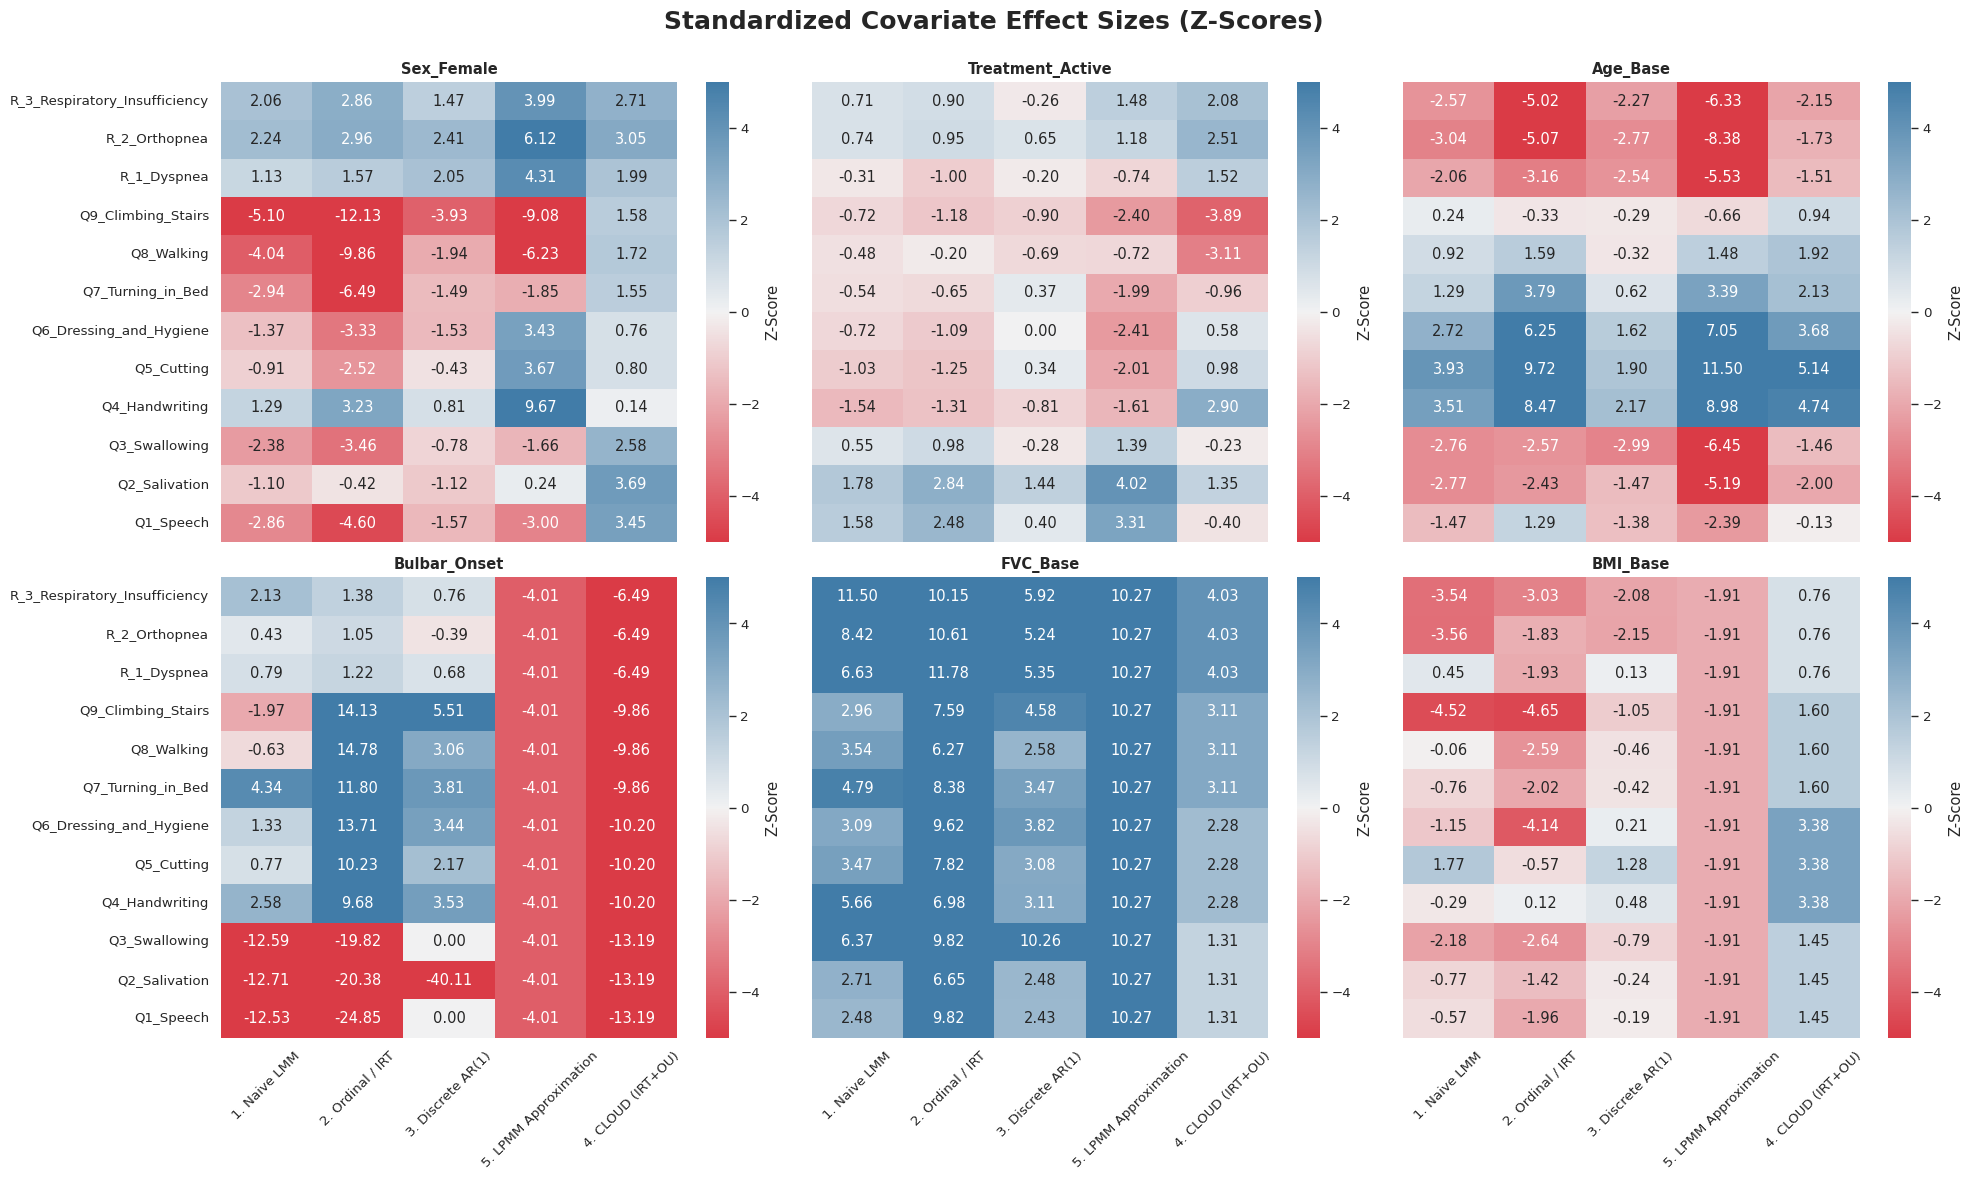

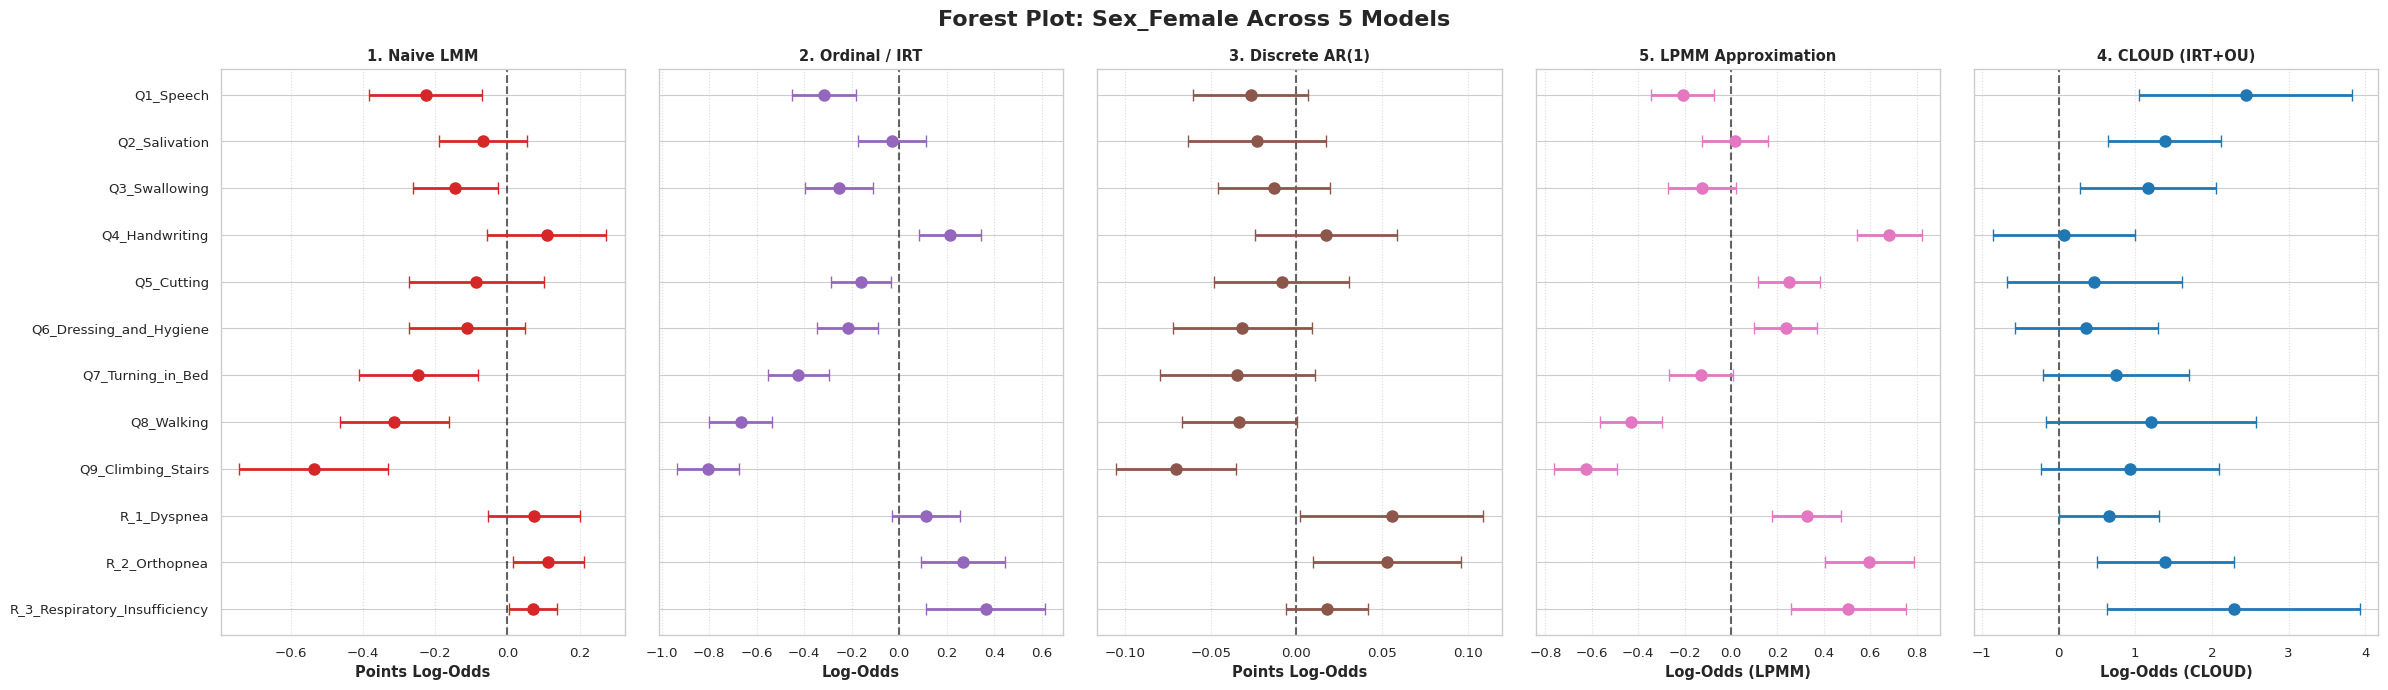

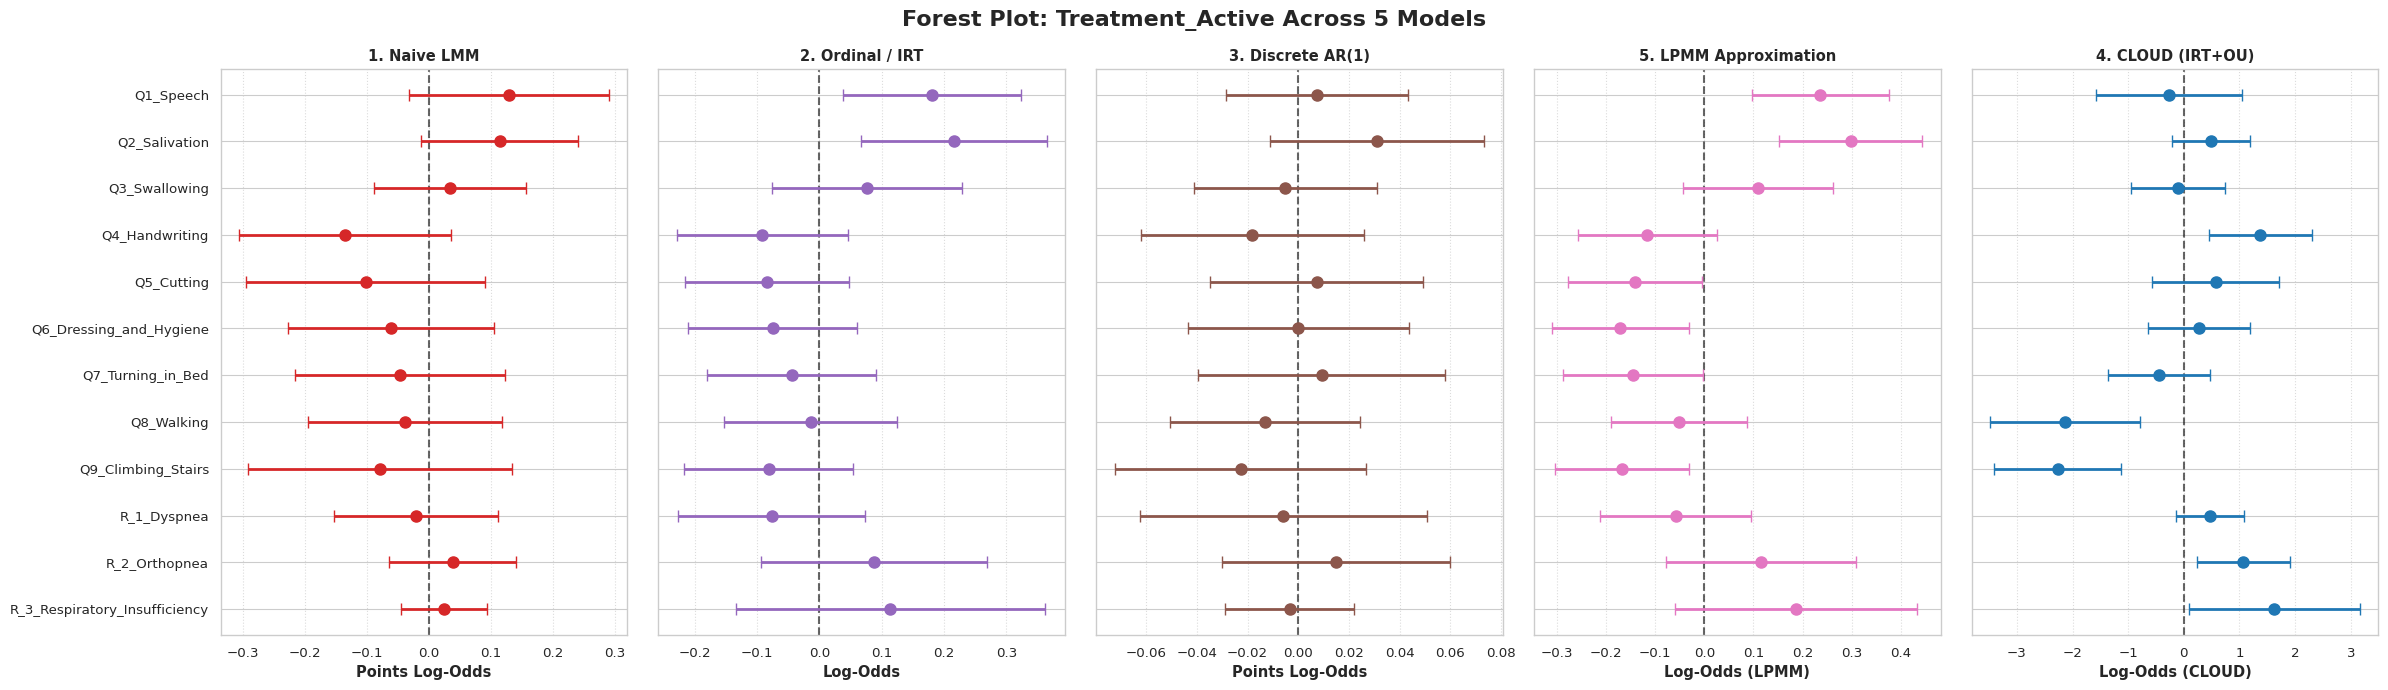

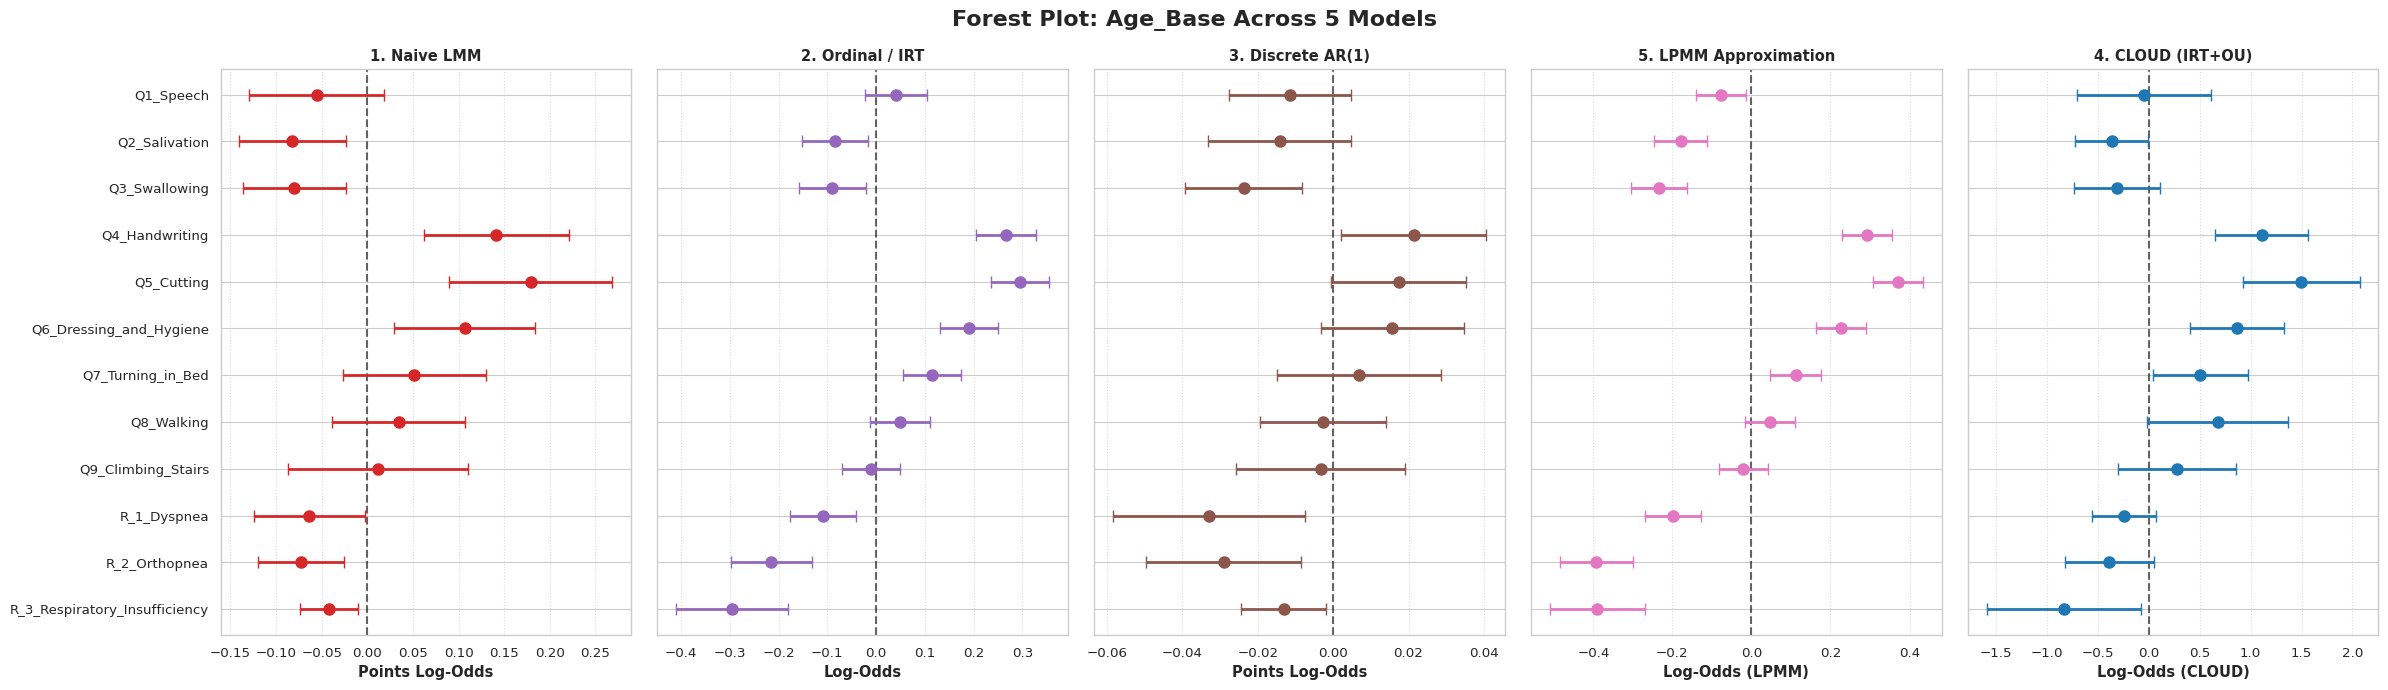

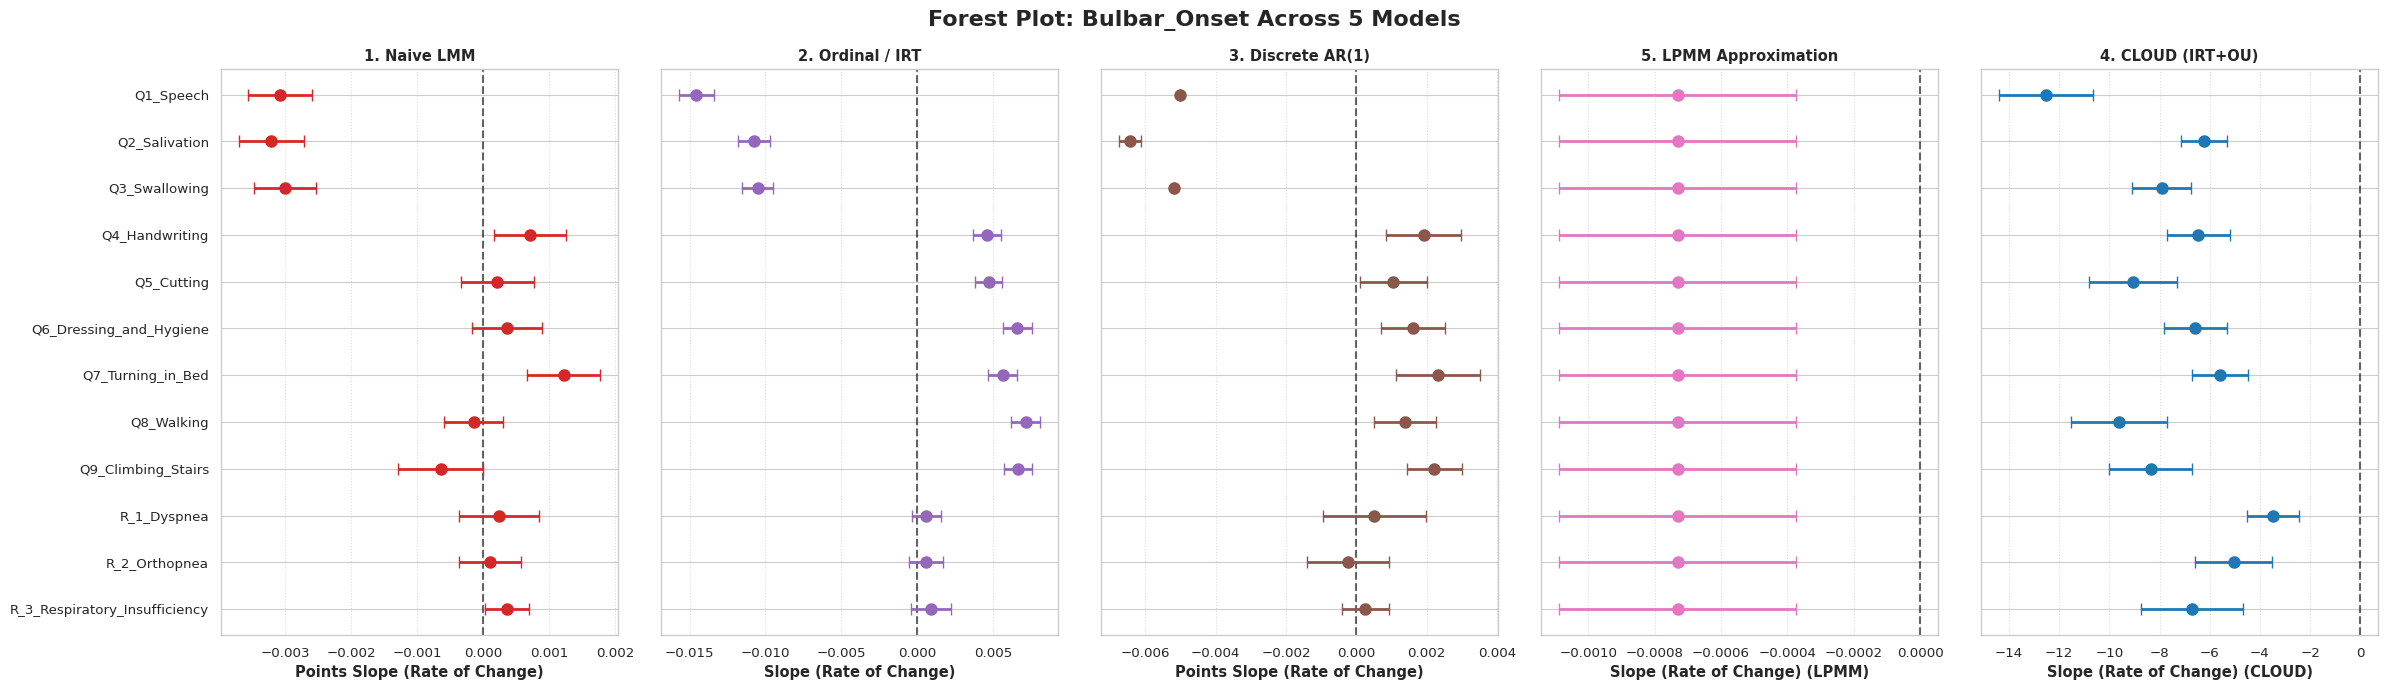

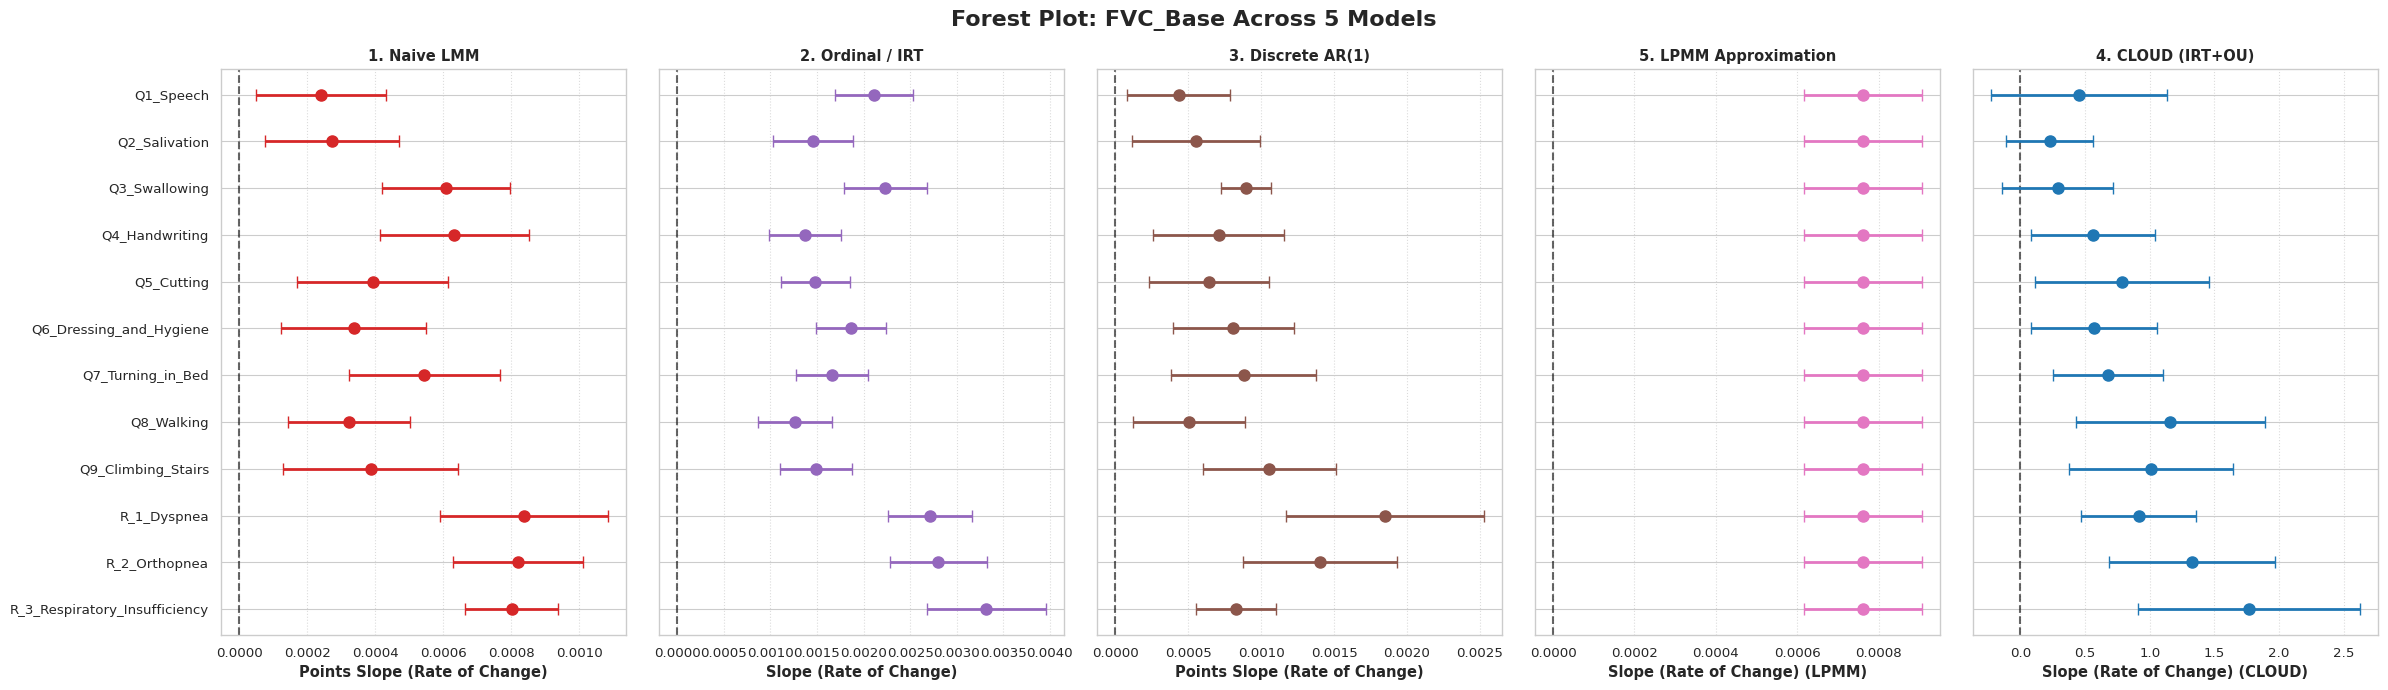

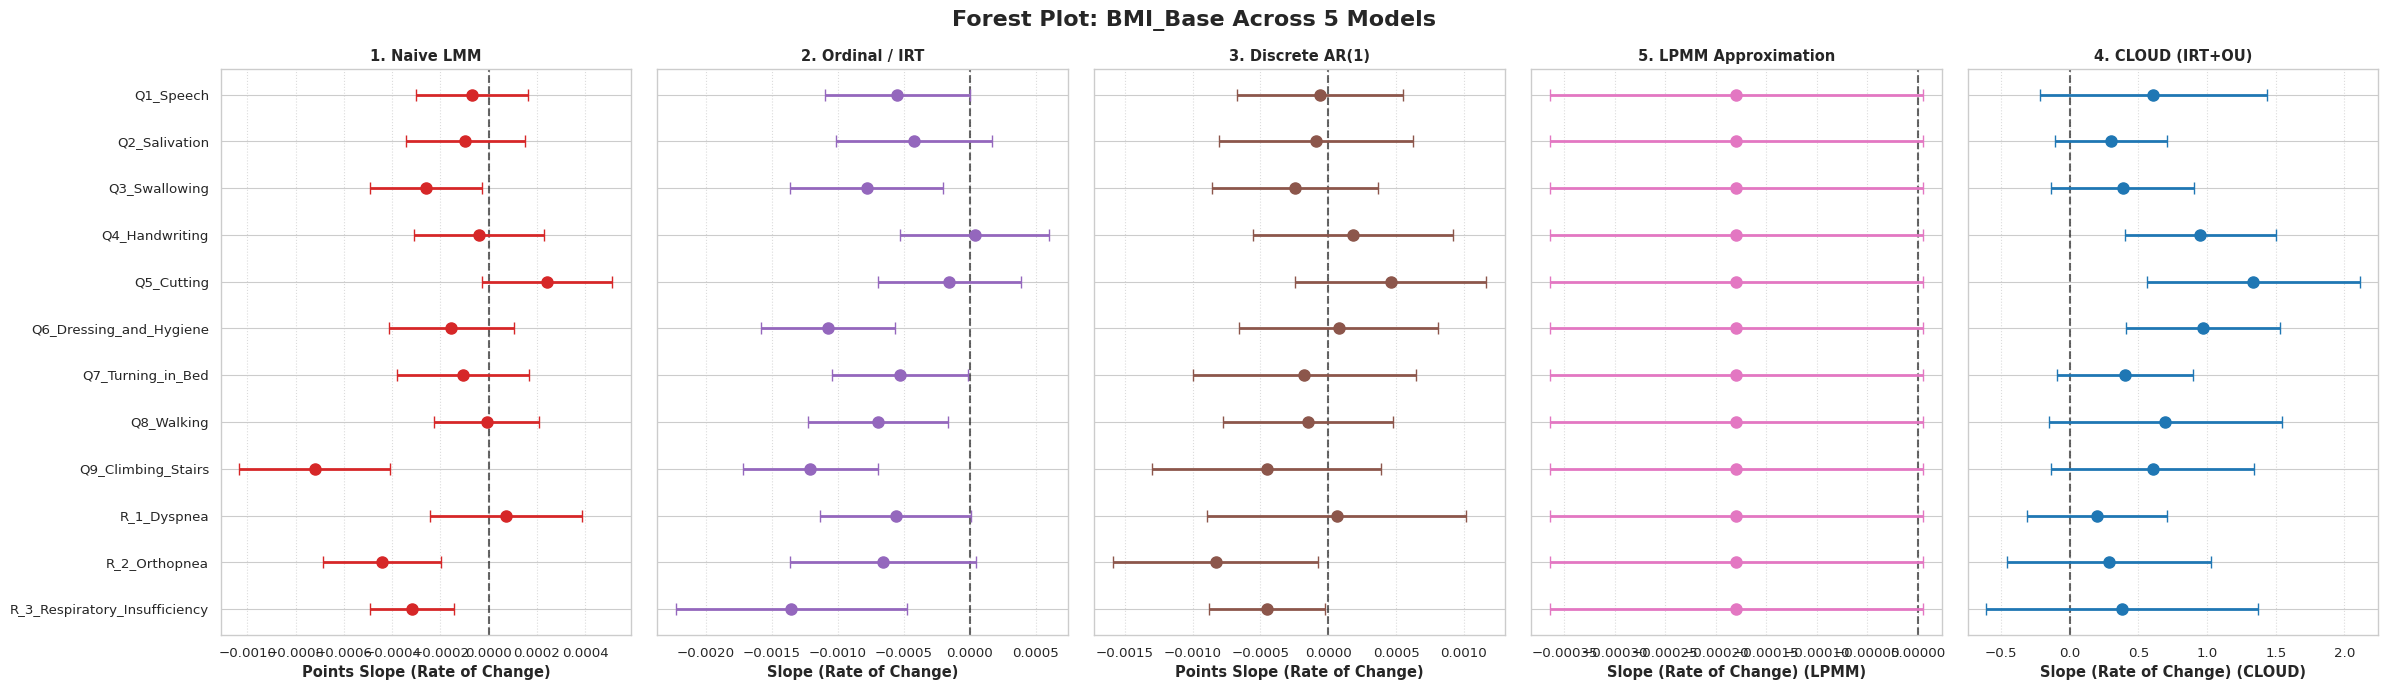

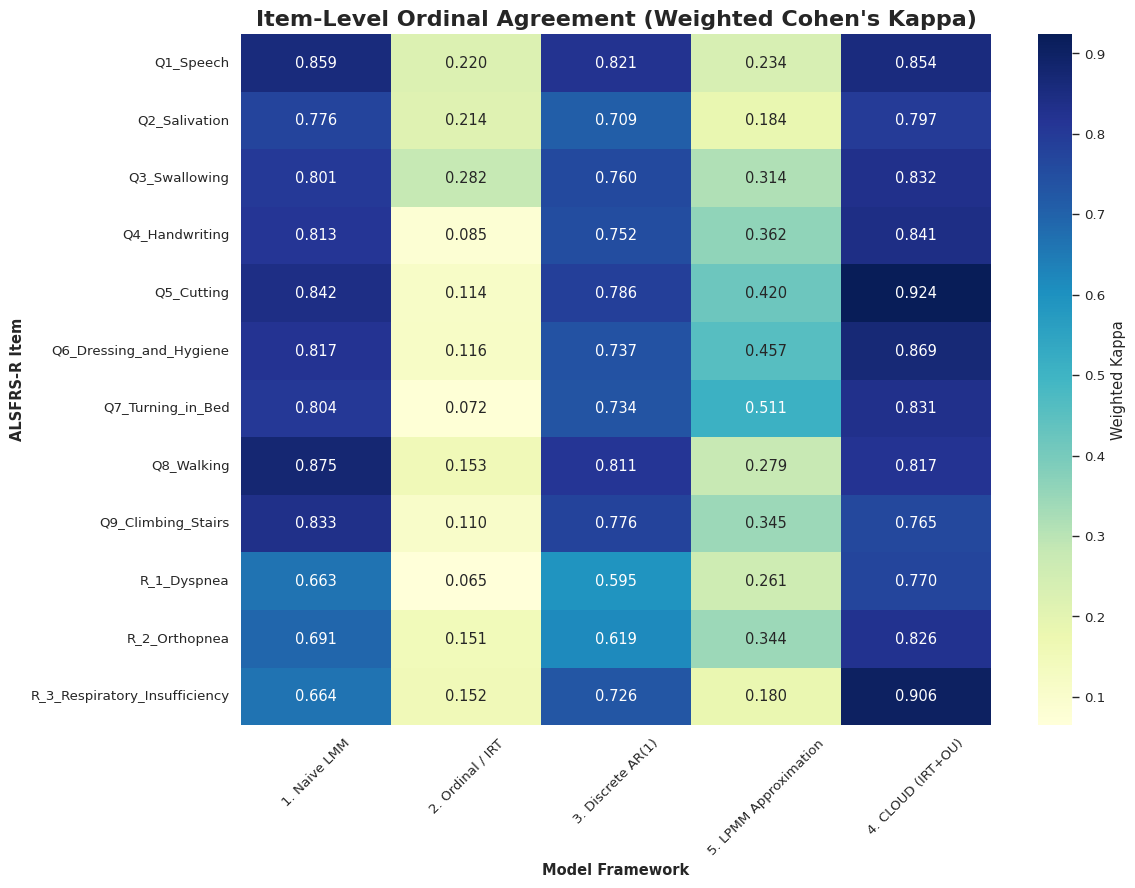

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from scipy.special import expit
from girth import grm_mml
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 5-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"         
MCMC_FILE = "../raw_results/results_S1_dahlou_ncp_cov_run1.csv" 

df = pd.read_csv(DATA_FILE)
df_mcmc = pd.read_csv(MCMC_FILE)

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations and lags
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Gap'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# FEATURE ENGINEERING: Time Interactions for Dynamic Covariates
for c in dyn_covariates:
    df[f'{c}_x_Time'] = df[c] * df['ALSFRS_Delta']
    df[f'{c}_x_Gap'] = df[c] * df['Time_Gap']

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])
dyn_gap_str = " + ".join([f"{c}_x_Gap" for c in dyn_covariates])

df['Total_Z'] = (df['Total Score'] - df['Total Score'].mean()) / df['Total Score'].std()

metrics_results = []
covariate_results = []

# --- SAFE EXTRACTION HELPERS ---
def get_z(m, term):
    try: 
        v = m.tvalues[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_se(m, term):
    try: 
        v = m.bse[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_est(m, term):
    try: 
        v = m.params[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def add_metrics(model_name, level, target, actual, expected):
    rmse = np.sqrt(mean_squared_error(actual, expected))
    mae = mean_absolute_error(actual, expected)
    if level == 'Item':
        pred_cat = np.clip(np.round(expected), 0, 4)
        exact = np.mean(pred_cat == actual) * 100
        kappa = cohen_kappa_score(actual, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    metrics_results.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact_Match_%': exact, 'Weighted_Kappa': kappa
    })

def get_irt_exp(theta, disc, diffs):
    p_ge = [expit(disc * (theta - th)) for th in diffs]
    p4, p3, p2, p1, p0 = p_ge[3], p_ge[2]-p_ge[3], p_ge[1]-p_ge[2], p_ge[0]-p_ge[1], 1.0-p_ge[0]
    return (0*p0) + (1*p1) + (2*p2) + (3*p3) + (4*p4)

# ==========================================
# 1. BASELINES 1-3 & 5: FIT & PREDICT
# ==========================================
print("\nFitting Baseline Models with Safe NaN Imputation...")

lpmm_dyn = smf.mixedlm(f"Total_Z ~ ALSFRS_Delta + {dyn_time_str}", data=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates]), groups=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates])["subject_id"]).fit(reml=False, disp=False)
df['Lambda_it'] = lpmm_dyn.fittedvalues
lpmm_dyn_z = {c: get_z(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_se = {c: get_se(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_est = {c: get_est(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}

for item in all_items:
    df['Item_Lag'] = df.groupby('subject_id')[item].shift(1) 
    req_cols = [item, 'Lambda_it', 'Item_Lag', 'Time_Gap', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]
    df_clean = df.dropna(subset=req_cols).copy()
    df_clean['Item_Cat'] = pd.Categorical(df_clean[item].astype(int), ordered=True)
    
    try: m1 = smf.mixedlm(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except: m1 = smf.ols(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean).fit()
    add_metrics('1. Naive LMM', 'Item', item, df_clean[item], np.clip(m1.fittedvalues, 0, 4))
    for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, c), 'SE': get_se(m1, c), 'Est': get_est(m1, c)})
    for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, f'{c}_x_Time'), 'SE': get_se(m1, f'{c}_x_Time'), 'Est': get_est(m1, f'{c}_x_Time')})

    try:
        exog_m2 = ['ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates]
        m2 = OrderedModel(df_clean['Item_Cat'], df_clean[exog_m2], distr='logit').fit(method='bfgs', disp=False)
        add_metrics('2. Ordinal / IRT', 'Item', item, df_clean[item], (m2.predict(df_clean[exog_m2]).values * np.arange(5)).sum(axis=1))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. Ordinal / IRT', 'Z_Score': get_z(m2, c), 'SE': get_se(m2, c), 'Est': get_est(m2, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. Ordinal / IRT', 'Z_Score': get_z(m2, f'{c}_x_Time'), 'SE': get_se(m2, f'{c}_x_Time'), 'Est': get_est(m2, f'{c}_x_Time')})
    except: pass

    try: m3 = smf.mixedlm(f"{item} ~ Item_Lag + Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except: m3 = smf.ols(f"{item} ~ Item_Lag + Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean).fit()
    add_metrics('3. Discrete AR(1)', 'Item', item, df_clean[item], np.clip(m3.fittedvalues, 0, 4))
    for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Discrete AR(1)', 'Z_Score': get_z(m3, c), 'SE': get_se(m3, c), 'Est': get_est(m3, c)})
    for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Discrete AR(1)', 'Z_Score': get_z(m3, f'{c}_x_Gap'), 'SE': get_se(m3, f'{c}_x_Gap'), 'Est': get_est(m3, f'{c}_x_Gap')})

    try:
        exog_m5 = ['Lambda_it'] + meas_covariates
        m5 = OrderedModel(df_clean['Item_Cat'], df_clean[exog_m5], distr='logit').fit(method='bfgs', disp=False)
        add_metrics('5. LPMM Approximation', 'Item', item, df_clean[item], (m5.predict(df_clean[exog_m5]).values * np.arange(5)).sum(axis=1))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '5. LPMM Approximation', 'Z_Score': get_z(m5, c), 'SE': get_se(m5, c), 'Est': get_est(m5, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '5. LPMM Approximation', 'Z_Score': lpmm_dyn_z[c], 'SE': lpmm_dyn_se[c], 'Est': lpmm_dyn_est[c]})
    except: pass

for target, items in scenarios.items():
    level = 'Overall' if target == 'Total Score' else 'Domain'
    max_val = 48 if level == 'Overall' else 12
    df_agg = df.dropna(subset=[target, 'Factor_Lag', 'Time_Gap', 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]).copy() if 'Factor_Lag' in df.columns else df.dropna(subset=[target, 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates]).copy()
    
    agg_form_1 = f"Q('{target}') ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}" if ' ' in target else f"{target} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
    try: agg1 = smf.mixedlm(agg_form_1, data=df_agg, groups=df_agg["subject_id"]).fit(reml=False, disp=False)
    except: agg1 = smf.ols(agg_form_1, data=df_agg).fit()
    add_metrics('1. Naive LMM', level, target, df_agg[target], np.clip(agg1.fittedvalues, 0, max_val))

    try:
        irt_res = grm_mml(df_agg[items].astype(int).values.T + 1)
        df_agg['theta'] = irt_res['Ability']
        m2_agg = smf.mixedlm(f"theta ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_agg, groups=df_agg["subject_id"]).fit(reml=False, disp=False)
        exp_val = np.zeros(len(df_agg))
        for i, item in enumerate(items): exp_val += get_irt_exp(m2_agg.fittedvalues, irt_res['Discrimination'][i], irt_res['Difficulty'][i])
        add_metrics('2. Ordinal / IRT', level, target, df_agg[target], exp_val)
    except: pass

    try:
        fa = FactorAnalyzer(n_factors=1, rotation=None).fit(df_agg[items])
        df_agg['Factor'] = fa.transform(df_agg[items])[:, 0]
        df_agg['Factor_Lag'] = df_agg.groupby('subject_id')['Factor'].shift(1)
        df_fa = df_agg.dropna(subset=['Factor_Lag', 'Time_Gap']).copy()
        m3_agg = smf.mixedlm(f"Factor ~ Factor_Lag + Time_Gap + {meas_str} + {dyn_gap_str}", data=df_fa, groups=df_fa["subject_id"]).fit(reml=False, disp=False)
        exp_fa = np.zeros(len(df_fa))
        for i, item in enumerate(items): exp_fa += np.clip((m3_agg.fittedvalues * fa.loadings_[:, 0][i]) + df_fa[items].mean().values[i], 0, 4)
        add_metrics('3. Discrete AR(1)', level, target, df_fa[target], exp_fa)
    except: pass

    exp_lpmm = np.zeros(len(df_agg))
    for item in items:
        df_agg['Item_Cat'] = pd.Categorical(df_agg[item].astype(int), ordered=True)
        try:
            m5_i = OrderedModel(df_agg['Item_Cat'], df_agg[['Lambda_it'] + meas_covariates], distr='logit').fit(method='bfgs', disp=False)
            exp_lpmm += (m5_i.predict(df_agg[['Lambda_it'] + meas_covariates]).values * np.arange(5)).sum(axis=1)
        except: pass
    add_metrics('5. LPMM Approximation', level, target, df_agg[target], exp_lpmm)

# ==========================================
# 2. EXTRACT CLOUD (MCMC) METRICS & COVS
# ==========================================
print("\nExtracting CLOUD (MCMC) Parameters (-Lambda * Phi mapped)...")

def ext_stan(param, shape):
    out = np.zeros(shape)
    for _, r in df_mcmc[df_mcmc['Parameter'].str.contains(rf"^{param}\[", regex=True)].iterrows():
        idx = [int(i)-1 for i in re.search(r'\[(.*?)\]', r['Parameter']).group(1).split(',')]
        if len(idx)==1: out[idx[0]] = r['Estimate']
        elif len(idx)==2: out[idx[0], idx[1]] = r['Estimate']
        elif len(idx)==3: out[idx[0], idx[1], idx[2]] = r['Estimate']
    return out

theta = ext_stan('theta', (12, 4))
lam   = ext_stan('lambda', (12,))
beta  = ext_stan('beta', (12, 3))
xi    = ext_stan('xi', (4, len(df)))
b     = ext_stan('b', (df['subject_id'].nunique(), 12))

X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].fillna(0).values
actual_sc = df[all_items].values
exp_sc = np.zeros((len(df), 12))
sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values

domain_idx = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8], 3: [9,10,11]}
for i in range(len(df)):
    for d, items in domain_idx.items():
        for k in items:
            eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
            p = [expit(1.0 * (eta - th)) for th in theta[k]]
            p4, p3, p2, p1, p0 = p[3], p[2]-p[3], p[1]-p[2], p[0]-p[1], 1.0-p[0]
            exp_sc[i,k] = (0*p0)+(1*p1)+(2*p2)+(3*p3)+(4*p4)

for k in range(12): add_metrics('4. CLOUD (IRT+OU)', 'Item', all_items[k], actual_sc[:,k], exp_sc[:,k])
for d, items in domain_idx.items(): add_metrics('4. CLOUD (IRT+OU)', 'Domain', list(domains.keys())[d], actual_sc[:,items].sum(axis=1), exp_sc[:,items].sum(axis=1))
add_metrics('4. CLOUD (IRT+OU)', 'Overall', 'Total Score', actual_sc.sum(axis=1), exp_sc.sum(axis=1))

cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

df_beta = df_mcmc[df_mcmc['Parameter'].str.contains(r'^beta\[', regex=True)].copy()
df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
for _, row in df_beta.iterrows():
    c_name = cov_map_beta[int(row['Cov_idx'])]
    item_name = all_items[int(row['Dim1']) - 1]
    est = row['Estimate']
    se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
    covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': '4. CLOUD (IRT+OU)', 'Z_Score': est/se if se!=0 else 0.0, 'SE': se, 'Est': est})

df_alpha = df_mcmc[df_mcmc['Parameter'].str.contains(r'^alpha_dyn\[', regex=True)].copy()
df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
for _, row in df_alpha.iterrows():
    c_name = cov_map_alpha[int(row['Cov_idx'])]
    dom_idx = int(row['Dim1']) - 1
    phi_est = row['Estimate']
    phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
    
    for k_idx in domain_idx[dom_idx]:
        item_name = all_items[k_idx]
        lam_k = lam[k_idx]
        if c_name in dyn_covariates:
            comp_est = lam_k * phi_est
        else:
            comp_est = -1 * lam_k * phi_est
        comp_se = abs(lam_k) * phi_se
        covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': '4. CLOUD (IRT+OU)', 'Z_Score': comp_est/comp_se if comp_se!=0 else 0.0, 'SE': comp_se, 'Est': comp_est})

# ==========================================
# 3. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")
df_metrics = pd.DataFrame(metrics_results).dropna(subset=['RMSE'])
df_metrics['Level'] = pd.Categorical(df_metrics['Level'], categories=['Overall', 'Domain', 'Item'], ordered=True)
df_metrics.to_csv("master_predictive_metrics.csv", index=False)

df_covs = pd.DataFrame(covariate_results)
df_covs['Item'] = pd.Categorical(df_covs['Item'], categories=reversed(all_items), ordered=True)
mod_order = ['1. Naive LMM', '2. Ordinal / IRT', '3. Discrete AR(1)', '5. LPMM Approximation', '4. CLOUD (IRT+OU)']
df_covs['Model'] = pd.Categorical(df_covs['Model'], categories=mod_order, ordered=True)

df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

# ==========================================
# 4. VISUALIZATION (Vector Graphics Enabled)
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

def save_multiformat(base_filename):
    plt.savefig(f"{base_filename}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{base_filename}.pdf", format='pdf', bbox_inches='tight')

model_colors = {
    '1. Naive LMM': '#d62728',          
    '2. Ordinal / IRT': '#9467bd',      
    '3. Discrete AR(1)': '#8c564b',     
    '5. LPMM Approximation': '#e377c2', 
    '4. CLOUD (IRT+OU)': '#1f77b4'      
}

# --- DATA PREP FOR MACRO PLOTS ---
df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()
target_order = ['Total Score', 'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory']
df_macro['Target'] = pd.Categorical(df_macro['Target'], categories=target_order, ordered=True)

# Plot A: Macro-Level RMSE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='RMSE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level RMSE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Root Mean Squared Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_A_Macro_RMSE')

# Plot B: Macro-Level MAE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='MAE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level MAE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Mean Absolute Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_B_Macro_MAE')

# Plot C: Covariate Heatmap
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True, sharex=True)
fig.suptitle("Standardized Covariate Effect Sizes (Z-Scores)", fontweight='bold', fontsize=18)
cmap = sns.diverging_palette(10, 240, as_cmap=True)
for i, cov in enumerate(all_covariates):
    ax = axes.flatten()[i]
    pivot = df_covs[df_covs['Covariate'] == cov].pivot(index='Item', columns='Model', values='Z_Score')
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, center=0, ax=ax, vmin=-5, vmax=5, cbar_kws={'label': 'Z-Score'})
    ax.set_title(cov, fontweight='bold')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
save_multiformat("Fig_C_Covariate_Heatmap")

# Plot D: Forest Plots
for cov in all_covariates:
    subset = df_covs[df_covs['Covariate'] == cov]
    fig, axes = plt.subplots(1, 5, figsize=(24, 7), sharey=True)
    fig.suptitle(f"Forest Plot: {cov} Across 5 Models", fontweight='bold', fontsize=16)
    base_unit = "Log-Odds" if cov in meas_covariates else "Slope (Rate of Change)"
    x_labels = [f"Points {base_unit}", f"{base_unit}", f"Points {base_unit}", f"{base_unit} (LPMM)", f"{base_unit} (CLOUD)"]
    
    for i, model in enumerate(mod_order):
        ax = axes[i]
        mod_data = subset[subset['Model'] == model].sort_values('Item')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        if not mod_data.empty:
            c_val = model_colors[model]
            ax.errorbar(mod_data['Est'], mod_data['Item'], xerr=mod_data['SE'] * 1.96, fmt='o', color=c_val, ecolor=c_val, elinewidth=2, capsize=4, markersize=8)
        ax.set_title(model, fontweight='bold')
        ax.set_xlabel(x_labels[i], fontweight='bold')
        ax.grid(True, axis='x', linestyle=':', alpha=0.7)
    plt.tight_layout()
    save_multiformat(f"Fig_D_Forest_{cov}")

# Plot E: Item-Level Ordinal Agreement (Kappa Heatmap)
plt.figure(figsize=(12, 9))
df_item = df_metrics[df_metrics['Level'] == 'Item']
kappa_pivot = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')[mod_order]
sns.heatmap(kappa_pivot, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Weighted Kappa'})
plt.title('Item-Level Ordinal Agreement (Weighted Cohen\'s Kappa)', fontweight='bold', fontsize=16)
plt.ylabel('ALSFRS-R Item', fontweight='bold')
plt.xlabel('Model Framework', fontweight='bold')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_multiformat('Fig_E_Item_Kappa_Heatmap')

# ==========================================
# 5. TERMINAL OUTPUT
# ==========================================
print("\n" + "="*95)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("="*95)
piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(piv_macro_rmse[mod_order].to_string(float_format="{:.3f}", na_rep="-"))

print("\n" + "="*95)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("="*95)
piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(piv_macro_mae[mod_order].to_string(float_format="{:.3f}", na_rep="-"))

print("\n" + "="*95)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("="*95)
piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')
print("--- ITEM EXACT MATCH % ---")
print(piv_item_exact[mod_order].to_string(float_format="{:.1f}", na_rep="-"))
print("\n--- ITEM WEIGHTED KAPPA ---")
print(piv_item_kappa[mod_order].to_string(float_format="{:.3f}", na_rep="-"))

print("\n" + "="*95)
print("TERMINAL EXPORT: COVARIATE Z-SCORES FOR AI ANALYSIS")
print("="*95)
for cov in all_covariates:
    print(f"\n---> {cov.upper()} <---")
    print(df_covs[df_covs['Covariate']==cov].pivot(index='Item', columns='Model', values='Z_Score')[mod_order].to_string(float_format="{:.3f}", na_rep="0.000"))

print("\n=== PIPELINE 100% COMPLETE ===")